In [17]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos

In [19]:
X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')
y_test = np.load('../data/processed/y_test.npy')

X_train_scaled = np.load('../data/processed/X_train_scaled.npy')
X_val_scaled = np.load('../data/processed/X_val_scaled.npy')
X_test_scaled = np.load('../data/processed/X_test_scaled.npy')

X_train_pca = np.load('../data/processed/X_train_pca.npy')
X_val_pca = np.load('../data/processed/X_val_pca.npy')
X_test_pca = np.load('../data/processed/X_test_pca.npy')

with open('../data/processed/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f"X_train shape: {X_train.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"--- VALIDATION SET ---")
print(f"X_val shape: {X_val.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")
print(f"X_val_pca shape: {X_val_pca.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"--- TEST SET ---")
print(f"X_test shape: {X_test.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (67229, 31)
X_train_scaled shape: (67229, 31)
X_train_pca shape: (67229, 19)
y_train shape: (67229,)
--- VALIDATION SET ---
X_val shape: (15175, 31)
X_val_scaled shape: (15175, 31)
X_val_pca shape: (15175, 19)
y_val shape: (15175,)
--- TEST SET ---
X_test shape: (22203, 31)
X_test_scaled shape: (22203, 31)
X_test_pca shape: (22203, 19)
y_test shape: (22203,)


## 2. Funciones de Evaluación

In [20]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Evalúa un modelo de regresión y retorna las métricas.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Resultados para: {model_name}")
    print(f"{'='*50}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

def plot_predictions(y_true, y_pred, model_name, ax=None):
    """
    Plotea predicciones vs valores reales.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.scatter(y_true, y_pred, alpha=0.5)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
    
    ax.set_xlabel('Rendimiento Real')
    ax.set_ylabel('Rendimiento Predicho')
    ax.set_title(f'{model_name}\nPredicciones vs Reales')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    r2 = r2_score(y_true, y_pred)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}', 
            transform=ax.transAxes, 
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

## 3. XGBoost sobre Features Originales (X)

In [21]:
print("Entrenando XGBoost sobre features originales (X)...")

xgb_x = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_x.fit(X_train, y_train)

y_train_pred_xgb_x = xgb_x.predict(X_train)
y_val_pred_xgb_x = xgb_x.predict(X_val)

print("\n--- CONJUNTO DE ENTRENAMIENTO ---")
results_xgb_x_train = evaluate_model(y_train, y_train_pred_xgb_x, "XGBoost (X) - Train")

print("\n--- CONJUNTO DE VALIDACIÓN ---")
results_xgb_x_val = evaluate_model(y_val, y_val_pred_xgb_x, "XGBoost (X) - Validation")

Entrenando XGBoost sobre features originales (X)...

--- CONJUNTO DE ENTRENAMIENTO ---

Resultados para: XGBoost (X) - Train
RMSE: 739.6988
MAE:  396.6945
R2:   0.9875

--- CONJUNTO DE VALIDACIÓN ---

Resultados para: XGBoost (X) - Validation
RMSE: 1179.5539
MAE:  590.8282
R2:   0.8761


## 4. Feature Importance para XGBoost (X)

In [22]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_x.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\nTop 15 features más importantes (XGBoost):")
print(feature_importance.head(15))


Top 15 features más importantes (XGBoost):
                  feature  importance
29       produccion_total    0.234115
30     sup_sembrada_total    0.200121
28        cultivo_encoded    0.176113
24         suelo_ind_prod    0.088861
26       suelo_profund_s1    0.085952
25        suelo_porc_sue1    0.080274
18     temperatura_mes_10    0.014090
1     precipitacion_mes_1    0.013576
20     temperatura_mes_11    0.011511
22     temperatura_mes_12    0.009818
2       temperatura_mes_2    0.009516
27  suelo_alcalin_encoded    0.008107
10      temperatura_mes_6    0.006404
14      temperatura_mes_8    0.005934
4       temperatura_mes_3    0.005636


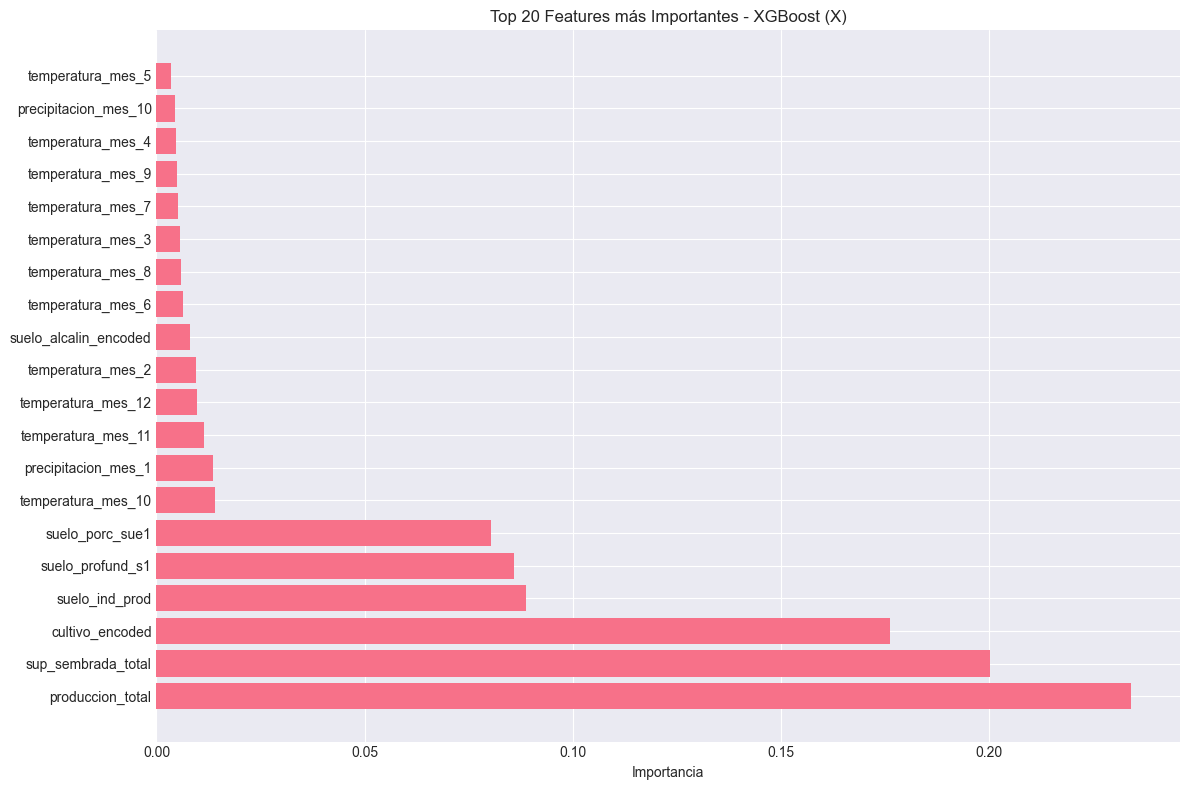

In [23]:
plt.figure(figsize=(12, 8))
top_n = 20
top_features = feature_importance.head(top_n)

plt.barh(range(top_n), top_features['importance'].values)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Importancia')
plt.title(f'Top {top_n} Features más Importantes - XGBoost (X)')
plt.tight_layout()
plt.savefig('../figures/xgb_x_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. XGBoost sobre Componentes Principales (Z)

In [24]:
print("Entrenando XGBoost sobre componentes principales (Z)...")

xgb_z = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_z.fit(X_train_pca, y_train)

y_train_pred_xgb_z = xgb_z.predict(X_train_pca)
y_val_pred_xgb_z = xgb_z.predict(X_val_pca)

print("\n--- CONJUNTO DE ENTRENAMIENTO ---")
results_xgb_z_train = evaluate_model(y_train, y_train_pred_xgb_z, "XGBoost (Z-PCA) - Train")

print("\n--- CONJUNTO DE VALIDACIÓN ---")
results_xgb_z_val = evaluate_model(y_val, y_val_pred_xgb_z, "XGBoost (Z-PCA) - Validation")

Entrenando XGBoost sobre componentes principales (Z)...

--- CONJUNTO DE ENTRENAMIENTO ---

Resultados para: XGBoost (Z-PCA) - Train
RMSE: 3284.7461
MAE:  1865.7450
R2:   0.7538

--- CONJUNTO DE VALIDACIÓN ---

Resultados para: XGBoost (Z-PCA) - Validation
RMSE: 2801.1354
MAE:  1675.5578
R2:   0.3013


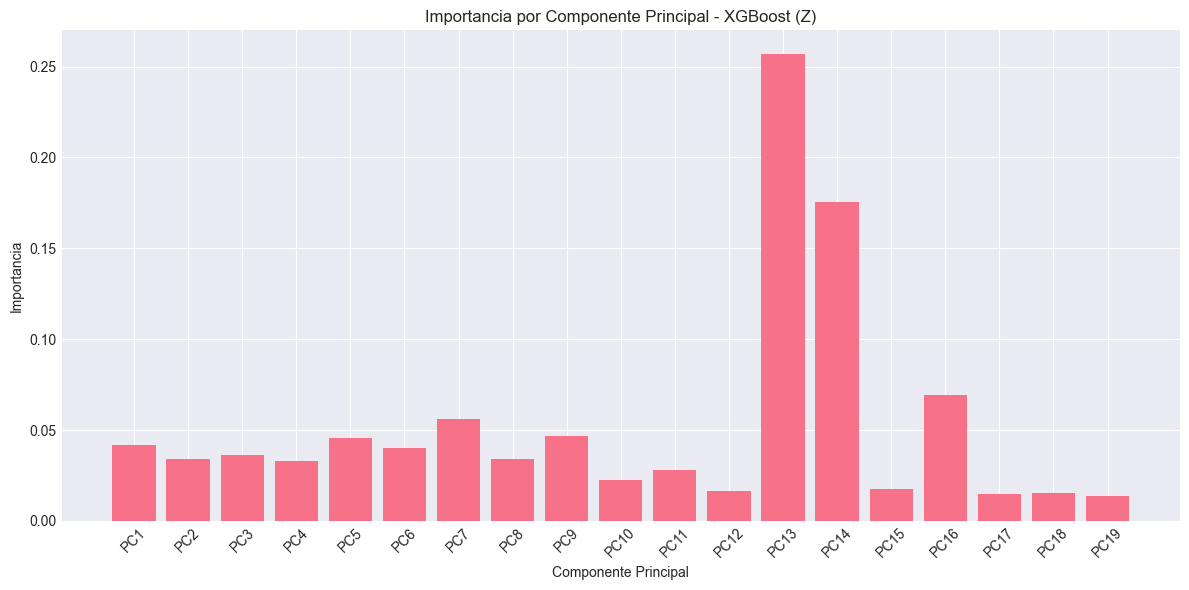

In [25]:
plt.figure(figsize=(12, 6))
pc_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
plt.bar(pc_names[:20], xgb_z.feature_importances_[:20])
plt.xlabel('Componente Principal')
plt.ylabel('Importancia')
plt.title('Importancia por Componente Principal - XGBoost (Z)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/xgb_z_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Comparación de Modelos XGBoost

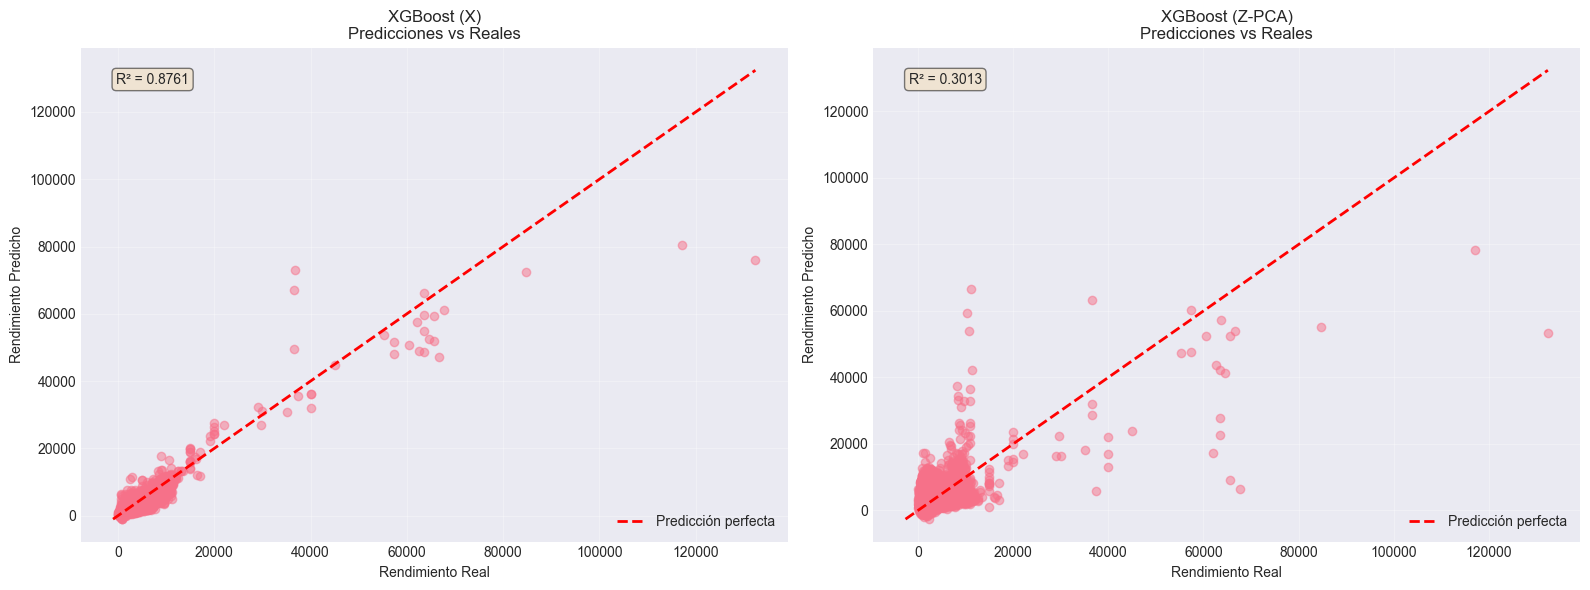

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_predictions(y_val, y_val_pred_xgb_x, "XGBoost (X)", ax=axes[0])
plot_predictions(y_val, y_val_pred_xgb_z, "XGBoost (Z-PCA)", ax=axes[1])

plt.tight_layout()
plt.savefig('../figures/xgb_predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
comparison_df = pd.DataFrame([
    results_xgb_x_val,
    results_xgb_z_val
])

print("\n" + "="*70)
print("COMPARACIÓN DE MODELOS XGBOOST (VALIDATION SET)")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


COMPARACIÓN DE MODELOS XGBOOST (VALIDATION SET)
                       model        rmse         mae       r2
    XGBoost (X) - Validation 1179.553865  590.828236 0.876095
XGBoost (Z-PCA) - Validation 2801.135385 1675.557816 0.301252


## 7. Comparación con Regresión Lineal

In [28]:
with open('../results/linear_regression_results.pkl', 'rb') as f:
    lr_results = pickle.load(f)

all_models_comparison = pd.DataFrame([
    lr_results['lr_x_val'],
    lr_results['lr_z_val'],
    results_xgb_x_val,
    results_xgb_z_val
])

print("\n" + "="*70)
print("COMPARACIÓN DE TODOS LOS MODELOS (VALIDATION SET)")
print("="*70)
print(all_models_comparison.to_string(index=False))
print("="*70)


COMPARACIÓN DE TODOS LOS MODELOS (VALIDATION SET)
                                 model        rmse         mae       r2
    Linear Regression (X) - Validation 3186.590903 1822.042463 0.095716
Linear Regression (Z-PCA) - Validation 3128.231027 1785.745667 0.128535
              XGBoost (X) - Validation 1179.553865  590.828236 0.876095
          XGBoost (Z-PCA) - Validation 2801.135385 1675.557816 0.301252


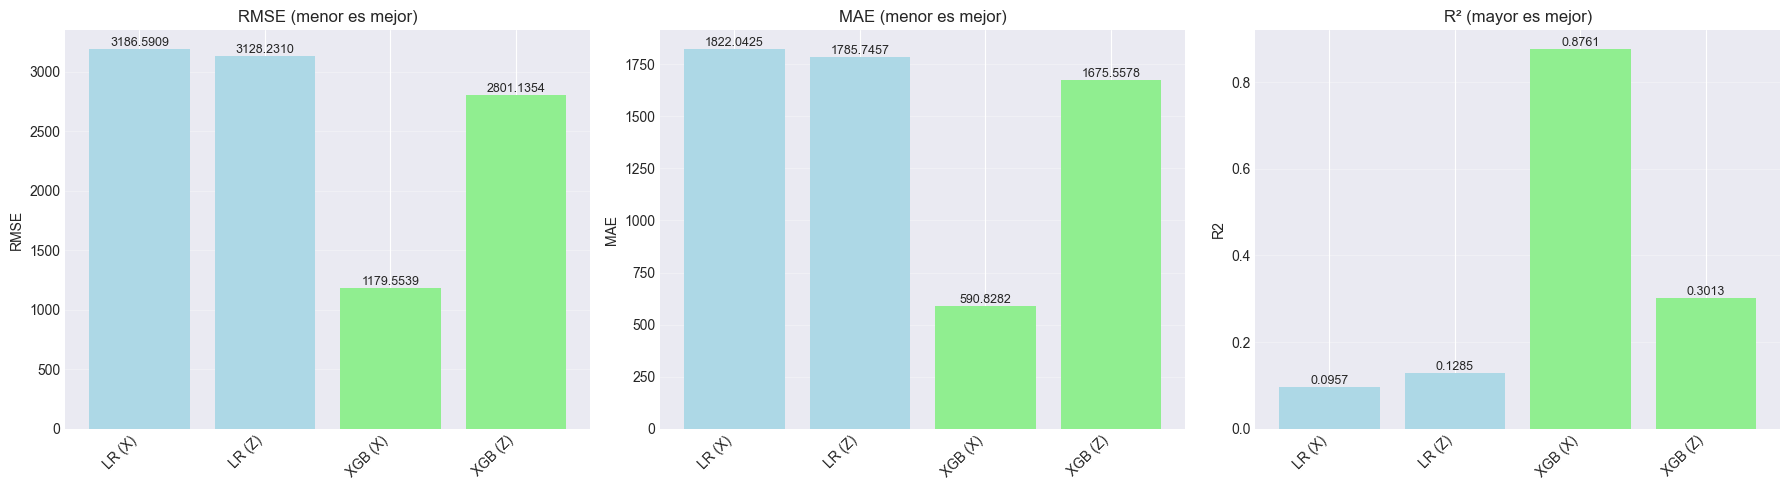

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['rmse', 'mae', 'r2']
titles = ['RMSE (menor es mejor)', 'MAE (menor es mejor)', 'R² (mayor es mejor)']
model_labels = ['LR (X)', 'LR (Z)', 'XGB (X)', 'XGB (Z)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    values = all_models_comparison[metric].values
    
    colors = ['lightblue', 'lightblue', 'lightgreen', 'lightgreen']
    axes[idx].bar(range(len(values)), values, color=colors)
    axes[idx].set_xticks(range(len(values)))
    axes[idx].set_xticklabels(model_labels, rotation=45, ha='right')
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Análisis de Residuos - XGBoost

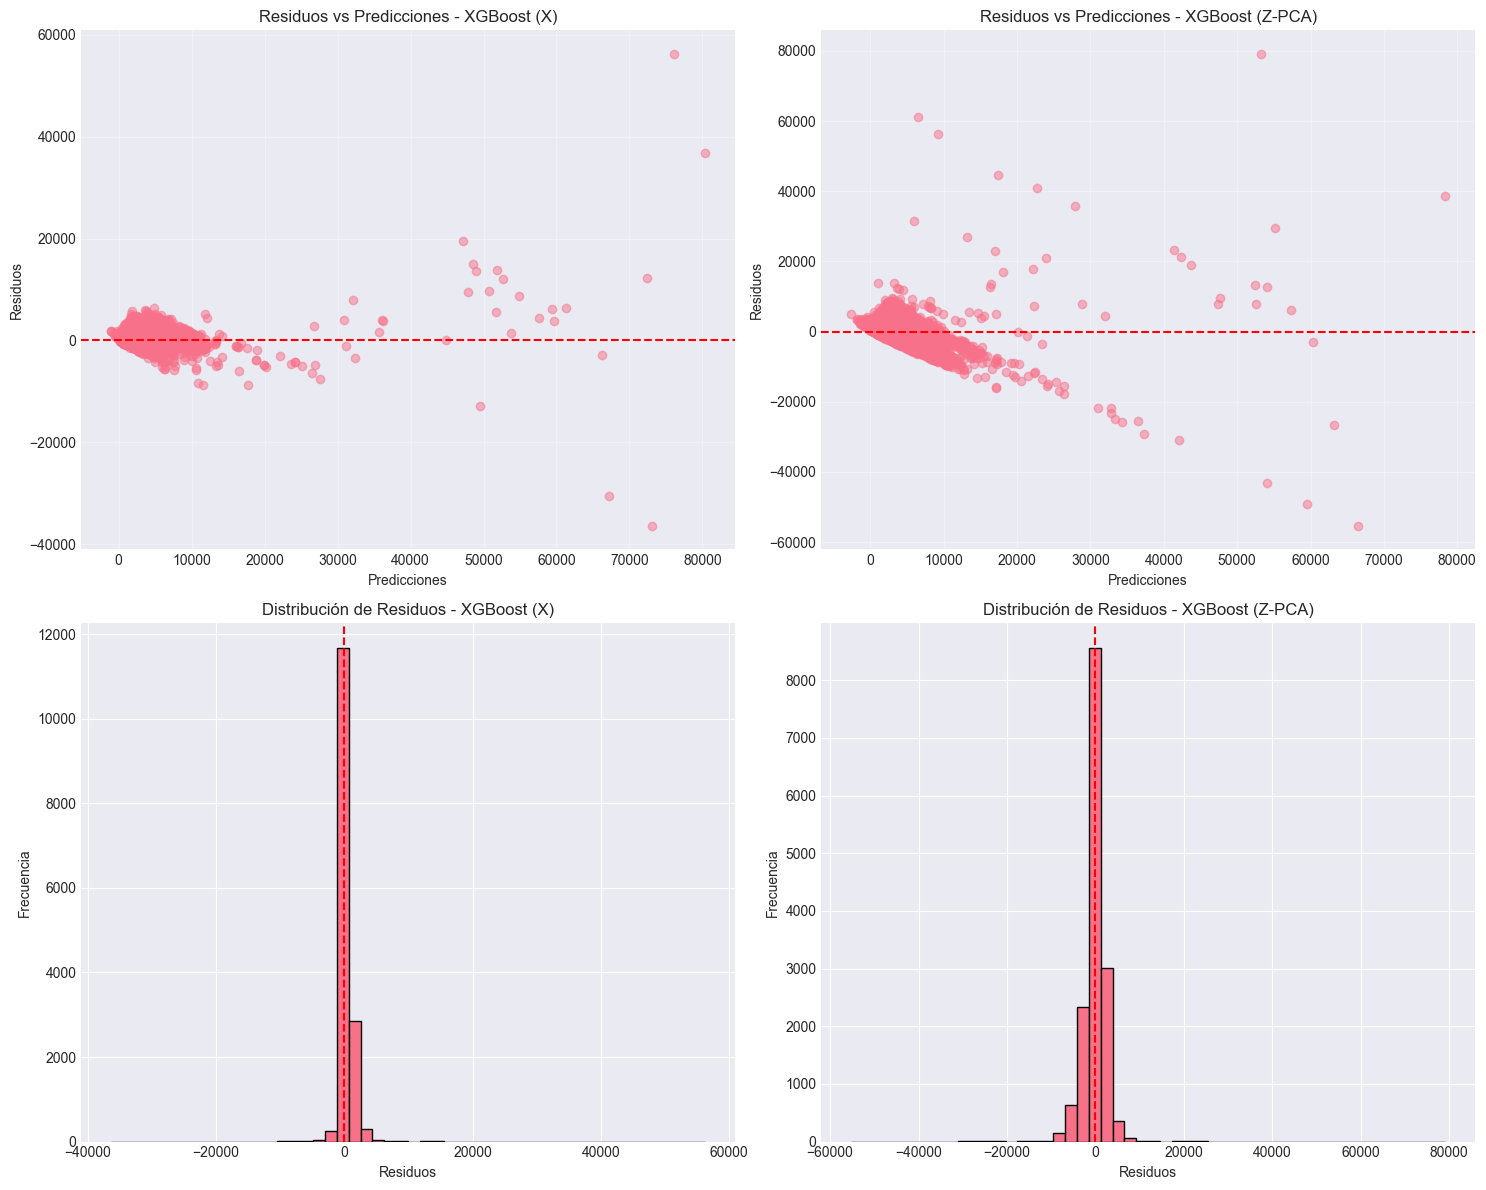

Media de residuos XGB(X): 312.6606
Std de residuos XGB(X): 1137.3613

Media de residuos XGB(Z): -152.6124
Std de residuos XGB(Z): 2796.9750


In [30]:
residuals_xgb_x = y_val - y_val_pred_xgb_x
residuals_xgb_z = y_val - y_val_pred_xgb_z

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].scatter(y_val_pred_xgb_x, residuals_xgb_x, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicciones')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Predicciones - XGBoost (X)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_val_pred_xgb_z, residuals_xgb_z, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicciones')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos vs Predicciones - XGBoost (Z-PCA)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(residuals_xgb_x, bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos - XGBoost (X)')
axes[1, 0].axvline(x=0, color='r', linestyle='--')

axes[1, 1].hist(residuals_xgb_z, bins=50, edgecolor='black')
axes[1, 1].set_xlabel('Residuos')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Residuos - XGBoost (Z-PCA)')
axes[1, 1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('../figures/xgb_residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Media de residuos XGB(X): {residuals_xgb_x.mean():.4f}")
print(f"Std de residuos XGB(X): {residuals_xgb_x.std():.4f}")
print(f"\nMedia de residuos XGB(Z): {residuals_xgb_z.mean():.4f}")
print(f"Std de residuos XGB(Z): {residuals_xgb_z.std():.4f}")

## 9. Guardar Modelos

In [31]:
with open('../models/xgb_x.pkl', 'wb') as f:
    pickle.dump(xgb_x, f)

with open('../models/xgb_z.pkl', 'wb') as f:
    pickle.dump(xgb_z, f)

print("Modelos XGBoost guardados exitosamente.")

Modelos XGBoost guardados exitosamente.


In [32]:
results_summary = {
    'xgb_x_train': results_xgb_x_train,
    'xgb_x_test': results_xgb_x_val,
    'xgb_z_train': results_xgb_z_train,
    'xgb_z_test': results_xgb_z_val
}

with open('../results/xgboost_results.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

print("Resultados XGBoost guardados exitosamente.")

Resultados XGBoost guardados exitosamente.
